In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

X_train = np.load(
    'outputs/X_train_healthcare.npy'
)

X_test = np.load(
    'outputs/X_test_healthcare.npy'
)

y_train = np.load(
    'outputs/y_train_healthcare.npy'
)

y_test = np.load(
    'outputs/y_test_healthcare.npy'
)

print(X_train.shape)
print(X_test.shape)

(2188, 18)
(400, 18)


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest trained successfully"
)

Random Forest trained successfully


In [4]:
y_pred = rf_model.predict(X_test)

y_proba = rf_model.predict_proba(
    X_test
)[:,1]

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred
)

rec = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_proba
)

print("="*40)
print("Healthcare - Random Forest")
print("="*40)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("="*40)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Retained',
            'Churned'
        ]
    )
)

Healthcare - Random Forest
Accuracy  : 0.6450
Precision : 0.7331
Recall    : 0.7546
F1 Score  : 0.7437
ROC-AUC   : 0.6340
              precision    recall  f1-score   support

    Retained       0.44      0.41      0.42       127
     Churned       0.73      0.75      0.74       273

    accuracy                           0.65       400
   macro avg       0.59      0.58      0.58       400
weighted avg       0.64      0.65      0.64       400



<Figure size 600x500 with 0 Axes>

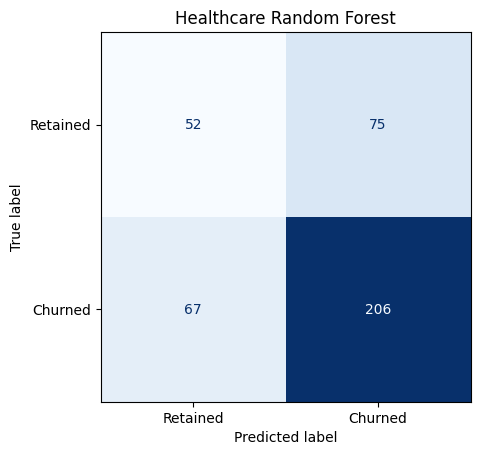

In [6]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Retained',
        'Churned'
    ]
)

plt.figure(figsize=(6,5))

disp.plot(
    cmap='Blues',
    colorbar=False
)

plt.title(
    'Healthcare Random Forest'
)

plt.show()

<Figure size 600x500 with 0 Axes>

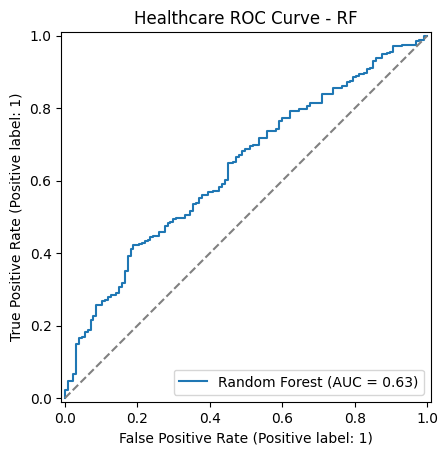

In [7]:
from sklearn.metrics import (
    RocCurveDisplay
)

plt.figure(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name='Random Forest'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.title(
    'Healthcare ROC Curve - RF'
)

plt.show()

In [8]:
feature_names = pd.read_csv(
    'outputs/healthcare_feature_names.csv'
).squeeze()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance_df.head(15)
)

                       Feature  Importance
9         Overall_Satisfaction    0.109910
8        Days_Since_Last_Visit    0.080806
13      Avg_Out_Of_Pocket_Cost    0.079475
3                Tenure_Months    0.076313
0                          Age    0.075390
17  Distance_To_Facility_Miles    0.072875
12             Provider_Rating    0.072746
7          Missed_Appointments    0.068620
10      Wait_Time_Satisfaction    0.065777
11          Staff_Satisfaction    0.060788
16              Referrals_Made    0.058852
6             Visits_Last_Year    0.053509
2                        State    0.038143
4                    Specialty    0.029255
1                       Gender    0.020136


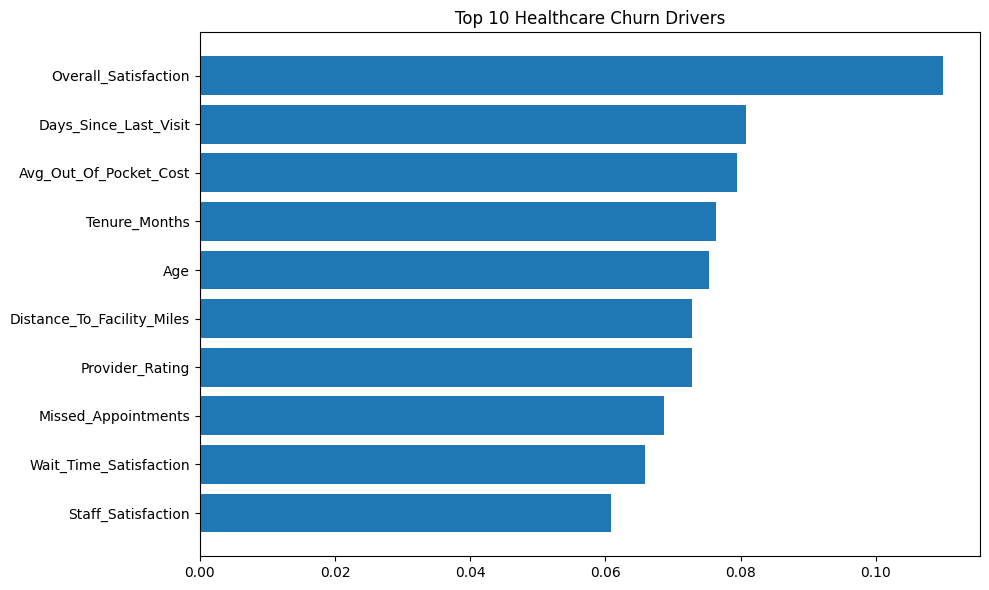

In [9]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.title(
    'Top 10 Healthcare Churn Drivers'
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [10]:
import joblib

joblib.dump(
    rf_model,
    'outputs/rf_model_healthcare.pkl'
)

print(
    "RF model saved"
)

RF model saved


In [11]:
results = {
    'Sector'    : 'Healthcare',
    'Model'     : 'Random Forest',
    'Accuracy'  : round(acc,4),
    'Precision' : round(prec,4),
    'Recall'    : round(rec,4),
    'F1'        : round(f1,4),
    'ROC_AUC'   : round(auc,4)
}

results_df = pd.DataFrame(
    [results]
)

results_df.to_csv(
    'outputs/results/healthcare_rf_results.csv',
    index=False
)

print(results_df)

       Sector          Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Healthcare  Random Forest     0.645     0.7331  0.7546  0.7437    0.634


In [12]:
importance_df.head(10)

,Feature,Importance
9,Overall_Satisfaction,0.109910
8,Days_Since_Last_Visit,0.080806
13,Avg_Out_Of_Pocket_Cost,0.079475
3,Tenure_Months,0.076313
0,Age,0.075390
17,Distance_To_Facility_Miles,0.072875
12,Provider_Rating,0.072746
7,Missed_Appointments,0.068620
10,Wait_Time_Satisfaction,0.065777
11,Staff_Satisfaction,0.060788
